In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

In [3]:
# Data preparation
import os

data_dir = "/content/drive/MyDrive/NIH_ChestXray_subset_split"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=f"{data_dir}/train", transform=transform)
val_dataset = datasets.ImageFolder(root=f"{data_dir}/val", transform=transform)
test_dataset = datasets.ImageFolder(root=f"{data_dir}/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

Train: 4501, Val: 963, Test: 969
Classes: ['Cardiomegaly', 'Effusion', 'No Finding', 'Pneumonia']


In [4]:
# Create train/val/test split if needed
import os
import shutil
import random
from sklearn.model_selection import train_test_split

def create_split(source_dir, dest_dir):
    if os.path.exists(dest_dir):
        return

    random.seed(42)
    os.makedirs(dest_dir, exist_ok=True)

    for split in ['train', 'val', 'test']:
        os.makedirs(f"{dest_dir}/{split}", exist_ok=True)

    class_dirs = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

    for class_name in class_dirs:
        class_path = os.path.join(source_dir, class_name)
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        random.shuffle(image_files)
        n_total = len(image_files)
        n_train = int(n_total * 0.7)
        n_val = int(n_total * 0.15)

        splits = {
            'train': image_files[:n_train],
            'val': image_files[n_train:n_train + n_val],
            'test': image_files[n_train + n_val:]
        }

        for split, files in splits.items():
            split_class_dir = f"{dest_dir}/{split}/{class_name}"
            os.makedirs(split_class_dir, exist_ok=True)
            for file in files:
                shutil.copy2(os.path.join(class_path, file), os.path.join(split_class_dir, file))

source_data_dir = "/content/drive/MyDrive/NIH_ChestXray_subset"
split_data_dir = "/content/drive/MyDrive/NIH_ChestXray_subset_split"

create_split(source_data_dir, split_data_dir)
print("Data split completed")

Data split completed


In [5]:
num_classes = 4  # No Finding, Pneumonia, Effusion, Cardiomegaly (following project deliverable)
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


# Base line code

In [6]:

# 3. Loss and optimizer - Address Class Imbalance
# For baseline, use unweighted loss first to see the class imbalance effect
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:

# 4. Enhanced Training and evaluation functions
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / len(loader), correct / total

In [8]:
# 5. Training loop

num_epochs = 5
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    print(f"Epoch {epoch+1}: "
          f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
          f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")


Epoch 1: Train Loss=0.3263, Train Acc=0.9300, Val Loss=0.4601, Val Acc=0.9335
Epoch 2: Train Loss=0.2985, Train Acc=0.9329, Val Loss=0.4445, Val Acc=0.9335
Epoch 3: Train Loss=0.2903, Train Acc=0.9329, Val Loss=0.4785, Val Acc=0.9304
Epoch 4: Train Loss=0.2878, Train Acc=0.9327, Val Loss=0.4820, Val Acc=0.9335
Epoch 5: Train Loss=0.2813, Train Acc=0.9327, Val Loss=0.4562, Val Acc=0.9335


BASELINE MODEL RESULTS
Final Test: Loss=0.3955, Acc=0.9298

Classification Report:
              precision    recall  f1-score   support

Cardiomegaly       0.00      0.00      0.00        15
    Effusion       0.00      0.00      0.00        47
  No Finding       0.93      1.00      0.96       901
   Pneumonia       0.00      0.00      0.00         6

    accuracy                           0.93       969
   macro avg       0.23      0.25      0.24       969
weighted avg       0.86      0.93      0.90       969



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


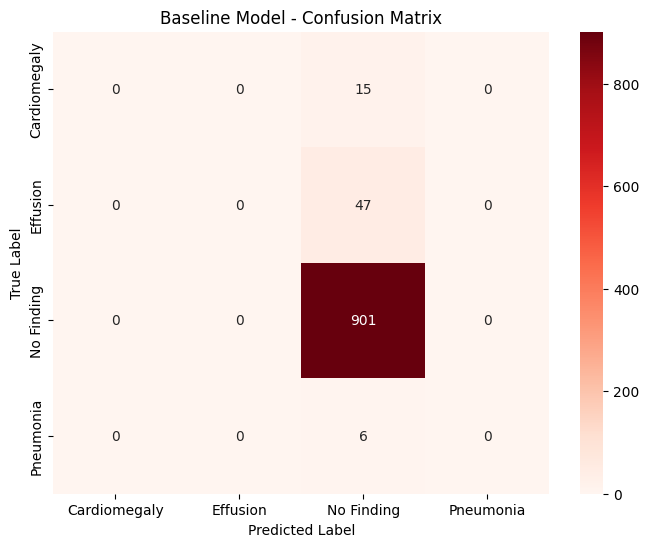


Per-class Metrics:
Cardiomegaly:
  Precision: 0.0000
  Recall:    0.0000
  F1-score:  0.0000
  Support:   15

Effusion:
  Precision: 0.0000
  Recall:    0.0000
  F1-score:  0.0000
  Support:   47

No Finding:
  Precision: 0.9298
  Recall:    1.0000
  F1-score:  0.9636
  Support:   901

Pneumonia:
  Precision: 0.0000
  Recall:    0.0000
  F1-score:  0.0000
  Support:   6



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
# 6. Final test evaluation with F1-score visualization

# Get detailed predictions for baseline model
def evaluate_with_predictions(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Store predictions and labels
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / len(loader), correct / total, all_preds, all_labels

# Evaluate baseline model with detailed metrics
test_loss, test_acc, test_preds_baseline, test_labels_baseline = evaluate_with_predictions(model, test_loader, criterion)

print("=" * 60)
print("BASELINE MODEL RESULTS")
print("=" * 60)
print(f"Final Test: Loss={test_loss:.4f}, Acc={test_acc:.4f}")
print()

# Import necessary libraries for detailed metrics
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Class names
class_names =  ['Cardiomegaly', 'Effusion', 'No Finding', 'Pneumonia']

# Detailed classification report
print("Classification Report:")
print(classification_report(test_labels_baseline, test_preds_baseline, target_names=class_names))

# Confusion Matrix
cm_baseline = confusion_matrix(test_labels_baseline, test_preds_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Baseline Model - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Calculate per-class metrics
precision_baseline, recall_baseline, f1_baseline, support_baseline = precision_recall_fscore_support(test_labels_baseline, test_preds_baseline)

print("\nPer-class Metrics:")
for i, class_name in enumerate(class_names):
    print(f"{class_name}:")
    print(f"  Precision: {precision_baseline[i]:.4f}")
    print(f"  Recall:    {recall_baseline[i]:.4f}")
    print(f"  F1-score:  {f1_baseline[i]:.4f}")
    print(f"  Support:   {support_baseline[i]}")
    print()


# Primary Model with Original Dataset

In [10]:
# Improved Model Implementation

import pandas as pd
import numpy as np
from torch.utils.data import Dataset, WeightedRandomSampler
from PIL import Image
import torch.nn.functional as F
from sklearn.utils.class_weight import compute_class_weight

# Load and analyze CSV data
csv_path = "/content/drive/MyDrive/NIH_ChestXray/Data_Entry_2017.csv"
if not os.path.exists(csv_path):
  print("Failed")

else:
  print("Success")

df = pd.read_csv(csv_path)

print("CSV Data Analysis:")
print(f"Total samples: {len(df)}")
print(f"Unique images: {df['Image Index'].nunique()}")
print(f"\nFinding Labels distribution:")
print(df['Finding Labels'].value_counts().head(10))

# Target diseases for 4-class classification (ImageFolderと同じ順序に統一)
TARGET_DISEASES = ['Cardiomegaly', 'Effusion', 'No Finding', 'Pneumonia']

def process_labels(finding_labels):
    """Process finding labels to match our 4-class problem"""
    if pd.isna(finding_labels):
        return 'No Finding'

    # Handle multiple findings (separated by |)
    findings = [f.strip() for f in str(finding_labels).split('|')]

    # Priority order for classification when multiple findings exist
    priority_order = ['Pneumonia', 'Cardiomegaly', 'Effusion', 'No Finding']

    for disease in priority_order:
        if disease in findings:
            return disease

    # If none of the target diseases found, classify as 'No Finding'
    return 'No Finding'

# Process labels
df['Processed_Label'] = df['Finding Labels'].apply(process_labels)

# Create label distribution
label_counts = df['Processed_Label'].value_counts()
print(f"\nProcessed Label Distribution:")
for label, count in label_counts.items():
    percentage = (count / len(df)) * 100
    print(f"  {label}: {count} ({percentage:.1f}%)")

# Create class to index mapping
class_to_idx = {cls: idx for idx, cls in enumerate(TARGET_DISEASES)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
print(f"\nClass mapping: {class_to_idx}")

# Custom Dataset Class with CSV Metadata (Multimodal)

class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None, class_to_idx=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.class_to_idx = class_to_idx or class_to_idx

        # Preprocess metadata for normalization
        self.age_mean = self.df['Patient Age'].mean()
        self.age_std = self.df['Patient Age'].std()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['Image Index'])

        # Load image
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a blank image if loading fails
            image = Image.new('RGB', (224, 224), color='black')

        if self.transform:
            image = self.transform(image)

        # Process metadata following project deliverable requirements
        # Age: normalized
        age = (row['Patient Age'] - self.age_mean) / self.age_std

        # Gender: binary encoding (M=1, F=0)
        gender = 1.0 if row['Patient Gender'] == 'M' else 0.0

        # View Position: binary encoding (PA=1, AP=0)
        view_position = 1.0 if row['View Position'] == 'PA' else 0.0

        # Combine metadata into tensor
        metadata = torch.FloatTensor([age, gender, view_position])

        # Get label
        label = self.class_to_idx[row['Processed_Label']]

        return image, metadata, label

# Enhanced data transforms with aggressive augmentation for minority classes
train_transform_improved = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(degrees=15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.3, saturation=0.2),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.RandomCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform_improved = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Multimodal dataset class and transforms defined.")
print("Metadata features: Age (normalized), Gender (M=1, F=0), View Position (PA=1, AP=0)")
print("Modified to use same subset as baseline model for fair comparison")

# Use the exact same directory as baseline (defined in earlier cells)
# Ensure consistency with baseline model data_dir
try:
    # Use data_dir from baseline if already defined
    baseline_data_dir = data_dir
    print(f"Using baseline data_dir: {baseline_data_dir}")
except NameError:
    # Fallback if data_dir not defined
    baseline_data_dir = "/content/drive/MyDrive/NIH_ChestXray_subset_split"
    print(f"Using fallback data directory: {baseline_data_dir}")

# Load the EXACT same ImageFolder datasets as baseline
from torchvision import datasets
baseline_train_imagefolder = datasets.ImageFolder(root=f"{baseline_data_dir}/train")
baseline_val_imagefolder = datasets.ImageFolder(root=f"{baseline_data_dir}/val")
baseline_test_imagefolder = datasets.ImageFolder(root=f"{baseline_data_dir}/test")

print(f"Using EXACT same baseline datasets:")
print(f"Train: {len(baseline_train_imagefolder)} samples")
print(f"Val: {len(baseline_val_imagefolder)} samples")
print(f"Test: {len(baseline_test_imagefolder)} samples")

def create_metadata_lookup(csv_df):
    """Create a lookup dictionary for fast metadata retrieval"""
    metadata_dict = {}
    for _, row in csv_df.iterrows():
        img_name = row['Image Index']
        metadata_dict[img_name] = {
            'age': row.get('Patient Age', 50),  # Default age if missing
            'gender': row.get('Patient Gender', 'M'),  # Default gender
            'view': row.get('View Position', 'PA')  # Default view
        }
    return metadata_dict

# Create metadata lookup for fast access
metadata_lookup = create_metadata_lookup(df)
print(f"Created metadata lookup for {len(metadata_lookup)} images")

# Simple Multimodal Dataset using ImageFolder + Metadata

class ImageFolderWithMetadata(Dataset):
    """Wrapper around ImageFolder that adds metadata from CSV"""

    def __init__(self, imagefolder_dataset, metadata_lookup, transform=None):
        self.imagefolder = imagefolder_dataset
        self.metadata_lookup = metadata_lookup
        self.transform = transform

        # Calculate metadata statistics for normalization
        ages = []
        for i in range(len(self.imagefolder)):
            img_path, _ = self.imagefolder.samples[i]
            img_name = os.path.basename(img_path)
            if img_name in self.metadata_lookup:
                age = self.metadata_lookup[img_name]['age']
                if pd.notna(age):
                    ages.append(float(age))

        if ages:
            self.age_mean = np.mean(ages)
            self.age_std = np.std(ages)
        else:
            self.age_mean = 50.0  # Default
            self.age_std = 15.0   # Default

    def __len__(self):
        return len(self.imagefolder)

    def __getitem__(self, idx):
        # Get image and label from ImageFolder
        img_path, label = self.imagefolder.samples[idx]
        img_name = os.path.basename(img_path)

        # Load and transform image
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Get metadata from lookup
        if img_name in self.metadata_lookup:
            metadata_info = self.metadata_lookup[img_name]
            age = float(metadata_info['age']) if pd.notna(metadata_info['age']) else 50.0
            gender = metadata_info['gender']
            view = metadata_info['view']
        else:
            # Use default values if no metadata found
            age = 50.0
            gender = 'M'
            view = 'PA'

        # Process metadata
        age_normalized = (age - self.age_mean) / self.age_std
        gender_encoded = 1.0 if gender == 'M' else 0.0
        view_encoded = 1.0 if view == 'PA' else 0.0

        metadata = torch.FloatTensor([age_normalized, gender_encoded, view_encoded])

        return image, metadata, label

# Create datasets using the exact same ImageFolder as baseline
train_dataset_improved = ImageFolderWithMetadata(
    baseline_train_imagefolder,
    metadata_lookup,
    train_transform_improved
)
val_dataset_improved = ImageFolderWithMetadata(
    baseline_val_imagefolder,
    metadata_lookup,
    val_test_transform_improved
)
test_dataset_improved = ImageFolderWithMetadata(
    baseline_test_imagefolder,
    metadata_lookup,
    val_test_transform_improved
)

print(f"Created improved datasets with metadata:")
print(f"Train: {len(train_dataset_improved)} samples")
print(f"Val: {len(val_dataset_improved)} samples")
print(f"Test: {len(test_dataset_improved)} samples")

# Create Weighted Sampler for Balanced Training

def create_weighted_sampler(dataset, target_labels, weight_smoothing='sqrt'):
    """Create a weighted sampler to handle class imbalance with smoothed weights"""
    # Get all labels from dataset (now returns 3 items: image, metadata, label)
    labels = [dataset[i][2] for i in range(len(dataset))]  # Changed index from 1 to 2

    # Calculate class counts
    class_counts = np.bincount(labels)
    print(f"Class counts for weighted sampler: {class_counts}")

    # Apply smoothed weighting to prevent over-correction
    if weight_smoothing == 'sqrt':
        # Use square root to reduce extreme weights
        class_weights = 1.0 / np.sqrt(class_counts)
    elif weight_smoothing == 'log':
        # Use logarithmic smoothing
        class_weights = 1.0 / np.log(class_counts + 1)
    else:
        # Original inverse frequency (not recommended)
        class_weights = 1.0 / class_counts

    print(f"Smoothed class weights ({weight_smoothing}): {class_weights}")

    # Create sample weights
    sample_weights = [class_weights[label] for label in labels]

    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

# Enhanced weighted sampler with stronger minority class emphasis
# Use ImageFolder labels directly
train_labels_list = [train_dataset_improved.imagefolder.samples[i][1] for i in range(len(train_dataset_improved))]

# Balanced weighted sampler - optimized for Pneumonia
def create_pneumonia_focused_sampler(dataset, target_labels):
    labels = [dataset[i][2] for i in range(len(dataset))]
    class_counts = np.bincount(labels)

    # Custom weighting: especially boost Pneumonia (class 3)
    class_weights = 1.0 / np.sqrt(class_counts)  # Base sqrt weighting
    class_weights[3] *= 2.0  # Extra boost for Pneumonia (index 3)

    print(f"Custom class weights: {dict(zip(TARGET_DISEASES, class_weights))}")
    sample_weights = [class_weights[label] for label in labels]

    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights) * 3,
        replacement=True
    )

train_sampler = create_pneumonia_focused_sampler(train_dataset_improved, train_labels_list)

# Custom collate function for multimodal data
def multimodal_collate_fn(batch):
    """Custom collate function to handle image, metadata, and labels"""
    images, metadata, labels = zip(*batch)

    # Stack images and labels as usual
    images = torch.stack(images, 0)
    labels = torch.LongTensor(labels)

    # Stack metadata
    metadata = torch.stack(metadata, 0)

    return images, metadata, labels

# Create data loaders with improved settings
train_loader_improved = DataLoader(
    train_dataset_improved,
    batch_size=32,
    sampler=train_sampler,
    num_workers=2,
    pin_memory=True,
    collate_fn=multimodal_collate_fn
)

val_loader_improved = DataLoader(
    val_dataset_improved,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=multimodal_collate_fn
)

test_loader_improved = DataLoader(
    test_dataset_improved,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=multimodal_collate_fn
)

print(f"Train batches: {len(train_loader_improved)}")
print(f"Val batches: {len(val_loader_improved)}")
print(f"Test batches: {len(test_loader_improved)}")

# Verify class distribution in training data
if len(train_dataset_improved) > 0:
    train_label_counts = np.bincount([train_dataset_improved[i][2] for i in range(len(train_dataset_improved))])
    print(f"Training set class distribution: {dict(zip(TARGET_DISEASES, train_label_counts))}")
else:
    print("No training data found - check subset directory and CSV matching")

# Multimodal Improved Model Architecture

class MultimodalChestXrayModel(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super(MultimodalChestXrayModel, self).__init__()

        # Image branch - CNN for visual feature extraction
        self.image_backbone = models.resnet50(pretrained=pretrained)

        # Freeze early layers to prevent overfitting
        for param in list(self.image_backbone.parameters())[:-40]:
            param.requires_grad = False

        # Remove the final classification layer from ResNet
        self.image_features = nn.Sequential(*list(self.image_backbone.children())[:-1])

        # Get number of features from ResNet50
        image_feature_dim = 2048  # ResNet50 output dimension

        # Metadata branch - MLP for tabular data (age, gender, view position)
        metadata_dim = 3  # age (normalized), gender (binary), view_position (binary: PA=1, AP=0)
        self.metadata_branch = nn.Sequential(
            nn.Linear(metadata_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        # Fusion layer - concatenate image and metadata features
        combined_feature_dim = image_feature_dim + 32  # 2048 + 32 = 2080

        # Enhanced classifier with attention mechanism for minority classes
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(combined_feature_dim, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.2),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.1),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, image, metadata):
        # Image branch
        image_features = self.image_features(image)
        image_features = torch.flatten(image_features, 1)  # Flatten to (batch_size, 2048)

        # Metadata branch
        metadata_features = self.metadata_branch(metadata)

        # Fusion - concatenate features
        combined_features = torch.cat([image_features, metadata_features], dim=1)

        # Final classification
        output = self.classifier(combined_features)

        return output

# Create multimodal improved model
model_improved = MultimodalChestXrayModel(num_classes=4, pretrained=True)
model_improved = model_improved.to(device)

# Calculate class weights for weighted loss
train_labels = [train_dataset_improved[i][2] for i in range(len(train_dataset_improved))]

# Get original balanced weights
balanced_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)

# Apply smoothing to prevent over-correction
alpha = 0.6  # Smoothing parameter (0=no weighting, 1=full balanced weighting)
uniform_weights = np.ones_like(balanced_weights)
smoothed_weights = alpha * balanced_weights + (1 - alpha) * uniform_weights

class_weights_tensor = torch.FloatTensor(smoothed_weights).to(device)

print(f"Original balanced weights: {dict(zip(TARGET_DISEASES, balanced_weights))}")
print(f"Smoothed weights (alpha={alpha}): {dict(zip(TARGET_DISEASES, smoothed_weights))}")

# Focal Loss for extreme imbalance
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Optimized Focal Loss for Pneumonia detection
# Reduce gamma for easier learning, boost Pneumonia alpha
pneumonia_focused_weights = class_weights_tensor.clone()
pneumonia_focused_weights[3] *= 3.0  # Triple weight for Pneumonia

criterion_improved = FocalLoss(alpha=pneumonia_focused_weights, gamma=1.5)  # Lower gamma for easier learning
optimizer_improved = optim.AdamW(model_improved.parameters(), lr=0.0003, weight_decay=0.01)

# Gentler learning rate scheduler for minority class learning
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_improved, mode='min', patience=5, factor=0.7, min_lr=1e-6
)

print("Multimodal improved model architecture ready (Image + Metadata).")
print(f"Model parameters: {sum(p.numel() for p in model_improved.parameters()):,}")

# Enhanced Training Functions (Multimodal)

def train_one_epoch_improved(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, metadata, labels) in enumerate(loader):
        images, metadata, labels = images.to(device), metadata.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, metadata)  # Pass both image and metadata
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Print progress every 100 batches
        if batch_idx % 100 == 0:
            print(f'Batch {batch_idx}/{len(loader)}, Loss: {loss.item():.4f}')

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

def evaluate_improved(model, loader, criterion, device, verbose=False):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, metadata, labels in loader:
            images, metadata, labels = images.to(device), metadata.to(device), labels.to(device)
            outputs = model(images, metadata)  # Pass both image and metadata
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    # Print class prediction distribution for monitoring
    if verbose:
        pred_counts = np.bincount(all_preds, minlength=len(TARGET_DISEASES))
        label_counts = np.bincount(all_labels, minlength=len(TARGET_DISEASES))
        print(f"  Predicted distribution: {dict(zip(TARGET_DISEASES, pred_counts))}")
        print(f"  True label distribution: {dict(zip(TARGET_DISEASES, label_counts))}")

    return epoch_loss, epoch_acc, all_preds, all_labels

Success
CSV Data Analysis:
Total samples: 112120
Unique images: 112120

Finding Labels distribution:
Finding Labels
No Finding                  60361
Infiltration                 9547
Atelectasis                  4215
Effusion                     3955
Nodule                       2705
Pneumothorax                 2194
Mass                         2139
Effusion|Infiltration        1603
Atelectasis|Infiltration     1350
Consolidation                1310
Name: count, dtype: int64

Processed Label Distribution:
  No Finding: 95949 (85.6%)
  Effusion: 12005 (10.7%)
  Cardiomegaly: 2735 (2.4%)
  Pneumonia: 1431 (1.3%)

Class mapping: {'Cardiomegaly': 0, 'Effusion': 1, 'No Finding': 2, 'Pneumonia': 3}
Multimodal dataset class and transforms defined.
Metadata features: Age (normalized), Gender (M=1, F=0), View Position (PA=1, AP=0)
Modified to use same subset as baseline model for fair comparison
Using baseline data_dir: /content/drive/MyDrive/NIH_ChestXray_subset_split
Using EXACT same baseli

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 180MB/s]


Original balanced weights: {'Cardiomegaly': np.float64(17.86111111111111), 'Effusion': np.float64(5.2094907407407405), 'No Finding': np.float64(0.26798047154084303), 'Pneumonia': np.float64(48.92391304347826)}
Smoothed weights (alpha=0.6): {'Cardiomegaly': np.float64(11.116666666666667), 'Effusion': np.float64(3.525694444444444), 'No Finding': np.float64(0.5607882829245059), 'Pneumonia': np.float64(29.754347826086953)}
Multimodal improved model architecture ready (Image + Metadata).
Model parameters: 28,284,364


In [11]:
# Train Improved Model with F1-score tracking

print("Starting training of improved model with F1-score tracking...")
print("=" * 60)

num_epochs_improved = 10
best_val_f1 = 0.0
patience_counter = 0
patience_limit = 8

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# F1-score tracking
train_f1_macro_improved = []
val_f1_macro_improved = []
train_f1_per_class_improved = []
val_f1_per_class_improved = []

for epoch in range(num_epochs_improved):
    print(f"\nEpoch {epoch+1}/{num_epochs_improved}")
    print("-" * 40)

    # Training phase
    train_loss, train_acc = train_one_epoch_improved(
        model_improved, train_loader_improved, optimizer_improved, criterion_improved, device
    )

    # Evaluation phase - get predictions for F1 calculation
    _, _, train_preds, train_labels = evaluate_improved(
        model_improved, train_loader_improved, criterion_improved, device, verbose=False
    )
    val_loss, val_acc, val_preds, val_labels = evaluate_improved(
        model_improved, val_loader_improved, criterion_improved, device, verbose=(epoch % 2 == 0)
    )

    # Calculate F1-scores
    from sklearn.metrics import f1_score
    train_f1_macro = f1_score(train_labels, train_preds, average='macro', zero_division=0)
    val_f1_macro = f1_score(val_labels, val_preds, average='macro', zero_division=0)

    train_f1_per_class = f1_score(train_labels, train_preds, average=None, zero_division=0)
    val_f1_per_class = f1_score(val_labels, val_preds, average=None, zero_division=0)

    # Update learning rate scheduler
    scheduler.step(val_loss)

    # Save metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    train_f1_macro_improved.append(train_f1_macro)
    val_f1_macro_improved.append(val_f1_macro)
    train_f1_per_class_improved.append(train_f1_per_class)
    val_f1_per_class_improved.append(val_f1_per_class)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1-Macro: {train_f1_macro:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1-Macro: {val_f1_macro:.4f}")

    # Early stopping based on macro F1-score (better for imbalanced data)
    if val_f1_macro > best_val_f1:
        best_val_f1 = val_f1_macro
        patience_counter = 0
        # Save best model
        torch.save(model_improved.state_dict(), 'best_improved_model.pth')
        print(f"New best validation F1-Macro: {best_val_f1:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience_limit:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

    # Display per-class F1-scores
    print("Per-class F1-scores (Validation):")
    for i, class_name in enumerate(TARGET_DISEASES):
        print(f"  {class_name}: {val_f1_per_class[i]:.4f}")

print(f"\nTraining completed. Best validation F1-Macro: {best_val_f1:.4f}")


Starting training of improved model with F1-score tracking...

Epoch 1/10
----------------------------------------
Batch 0/422, Loss: 17.7039
Batch 100/422, Loss: 2.9967
Batch 200/422, Loss: 1.9949
Batch 300/422, Loss: 1.0354
Batch 400/422, Loss: 1.4822
  Predicted distribution: {'Cardiomegaly': np.int64(302), 'Effusion': np.int64(306), 'No Finding': np.int64(281), 'Pneumonia': np.int64(74)}
  True label distribution: {'Cardiomegaly': np.int64(13), 'Effusion': np.int64(46), 'No Finding': np.int64(899), 'Pneumonia': np.int64(5)}
Train Loss: 3.1092, Train Acc: 0.3428, Train F1-Macro: 0.5053
Val Loss: 11.8504, Val Acc: 0.3292, Val F1-Macro: 0.1792
New best validation F1-Macro: 0.1792
Per-class F1-scores (Validation):
  Cardiomegaly: 0.0762
  Effusion: 0.1761
  No Finding: 0.4644
  Pneumonia: 0.0000

Epoch 2/10
----------------------------------------
Batch 0/422, Loss: 0.6738
Batch 100/422, Loss: 0.3470
Batch 200/422, Loss: 0.7450
Batch 300/422, Loss: 1.8212
Batch 400/422, Loss: 0.4960
Tr

  Predicted distribution: {'Cardiomegaly': np.int64(13), 'Effusion': np.int64(113), 'No Finding': np.int64(840), 'Pneumonia': np.int64(3)}
  True label distribution: {'Cardiomegaly': np.int64(15), 'Effusion': np.int64(47), 'No Finding': np.int64(901), 'Pneumonia': np.int64(6)}
IMPROVED MODEL RESULTS
Final Test: Loss=13.5176, Acc=0.8638

Classification Report:
              precision    recall  f1-score   support

Cardiomegaly       0.38      0.33      0.36        15
    Effusion       0.23      0.55      0.33        47
  No Finding       0.96      0.89      0.92       901
   Pneumonia       0.33      0.17      0.22         6

    accuracy                           0.86       969
   macro avg       0.48      0.49      0.46       969
weighted avg       0.91      0.86      0.88       969



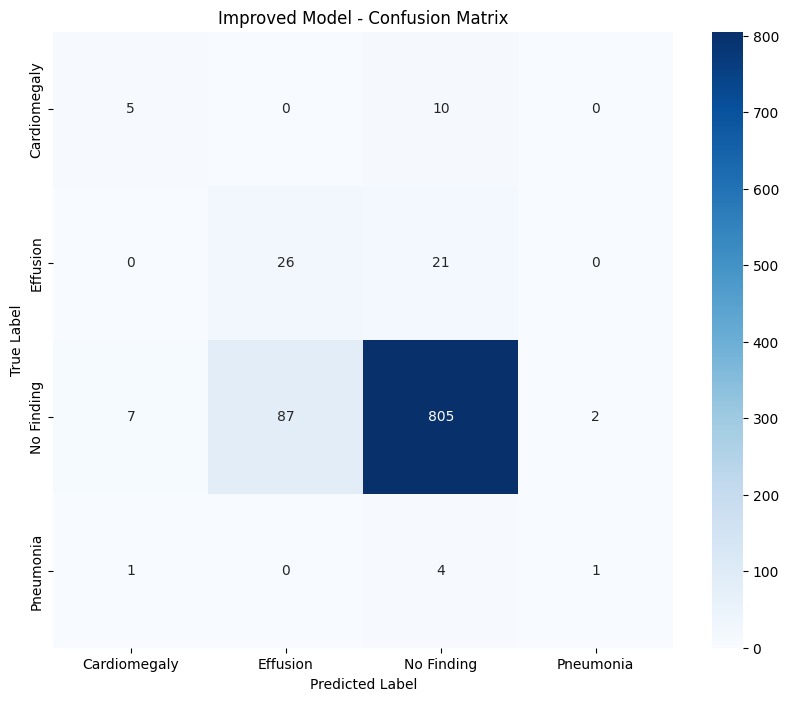


Per-class Metrics:
Cardiomegaly:
  Precision: 0.3846
  Recall:    0.3333
  F1-score:  0.3571
  Support:   15

Effusion:
  Precision: 0.2301
  Recall:    0.5532
  F1-score:  0.3250
  Support:   47

No Finding:
  Precision: 0.9583
  Recall:    0.8935
  F1-score:  0.9248
  Support:   901

Pneumonia:
  Precision: 0.3333
  Recall:    0.1667
  F1-score:  0.2222
  Support:   6



In [12]:
# Evaluate Improved Model with F1-score visualization

# Load best model
model_improved.load_state_dict(torch.load('best_improved_model.pth'))

# Evaluate on test set
test_loss, test_acc, test_preds_improved, test_labels_improved = evaluate_improved(
    model_improved, test_loader_improved, criterion_improved, device, verbose=True
)

print("=" * 60)
print("IMPROVED MODEL RESULTS")
print("=" * 60)
print(f"Final Test: Loss={test_loss:.4f}, Acc={test_acc:.4f}")
print()

# Import necessary libraries for detailed metrics
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

# Detailed classification report
print("Classification Report:")
print(classification_report(test_labels_improved, test_preds_improved, target_names=TARGET_DISEASES))

# Confusion Matrix
cm_improved = confusion_matrix(test_labels_improved, test_preds_improved)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Blues',
            xticklabels=TARGET_DISEASES, yticklabels=TARGET_DISEASES)
plt.title('Improved Model - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Calculate per-class metrics
precision_improved, recall_improved, f1_improved, support_improved = precision_recall_fscore_support(
    test_labels_improved, test_preds_improved
)

print("\nPer-class Metrics:")
for i, class_name in enumerate(TARGET_DISEASES):
    print(f"{class_name}:")
    print(f"  Precision: {precision_improved[i]:.4f}")
    print(f"  Recall:    {recall_improved[i]:.4f}")
    print(f"  F1-score:  {f1_improved[i]:.4f}")
    print(f"  Support:   {support_improved[i]}")
    print()


# Primary Model with New Dataset

In [13]:
# Improved Model Implementation

import pandas as pd
import numpy as np
from torch.utils.data import Dataset, WeightedRandomSampler
from PIL import Image
import torch.nn.functional as F
from sklearn.utils.class_weight import compute_class_weight

# Load and analyze CSV data
csv_path = "/content/drive/MyDrive/NIH_ChestXray/Data_Entry_2017.csv"
if not os.path.exists(csv_path):
  print("Failed")

else:
  print("Success")

df = pd.read_csv(csv_path)

print("CSV Data Analysis:")
print(f"Total samples: {len(df)}")
print(f"Unique images: {df['Image Index'].nunique()}")
print(f"\nFinding Labels distribution:")
print(df['Finding Labels'].value_counts().head(10))

# Target diseases for 4-class classification (ImageFolderと同じ順序に統一)
TARGET_DISEASES = ['Cardiomegaly', 'Effusion', 'No Finding', 'Pneumonia']

def process_labels(finding_labels):
    """Process finding labels to match our 4-class problem"""
    if pd.isna(finding_labels):
        return 'No Finding'

    # Handle multiple findings (separated by |)
    findings = [f.strip() for f in str(finding_labels).split('|')]

    # Priority order for classification when multiple findings exist
    priority_order = ['Pneumonia', 'Cardiomegaly', 'Effusion', 'No Finding']

    for disease in priority_order:
        if disease in findings:
            return disease

    # If none of the target diseases found, classify as 'No Finding'
    return 'No Finding'

# Process labels
df['Processed_Label'] = df['Finding Labels'].apply(process_labels)

# Create label distribution
label_counts = df['Processed_Label'].value_counts()
print(f"\nProcessed Label Distribution:")
for label, count in label_counts.items():
    percentage = (count / len(df)) * 100
    print(f"  {label}: {count} ({percentage:.1f}%)")

# Create class to index mapping
class_to_idx = {cls: idx for idx, cls in enumerate(TARGET_DISEASES)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
print(f"\nClass mapping: {class_to_idx}")

# Custom Dataset Class with CSV Metadata (Multimodal)

class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None, class_to_idx=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.class_to_idx = class_to_idx or class_to_idx

        # Preprocess metadata for normalization
        self.age_mean = self.df['Patient Age'].mean()
        self.age_std = self.df['Patient Age'].std()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['Image Index'])

        # Load image
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a blank image if loading fails
            image = Image.new('RGB', (224, 224), color='black')

        if self.transform:
            image = self.transform(image)

        # Process metadata following project deliverable requirements
        # Age: normalized
        age = (row['Patient Age'] - self.age_mean) / self.age_std

        # Gender: binary encoding (M=1, F=0)
        gender = 1.0 if row['Patient Gender'] == 'M' else 0.0

        # View Position: binary encoding (PA=1, AP=0)
        view_position = 1.0 if row['View Position'] == 'PA' else 0.0

        # Combine metadata into tensor
        metadata = torch.FloatTensor([age, gender, view_position])

        # Get label
        label = self.class_to_idx[row['Processed_Label']]

        return image, metadata, label

# Enhanced data transforms with aggressive augmentation for minority classes
train_transform_improved = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(degrees=15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.3, saturation=0.2),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.RandomCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform_improved = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Multimodal dataset class and transforms defined.")
print("Metadata features: Age (normalized), Gender (M=1, F=0), View Position (PA=1, AP=0)")
print("Modified to use new reduced dataset for Primary Model evaluation")

# Use the new reduced dataset for Primary Model evaluation
new_data_dir = "/content/drive/MyDrive/NIH_ChestXray_subset_010_split_reduced"
print(f"Using new reduced dataset directory: {new_data_dir}")

# Load the ImageFolder datasets from new reduced dataset
from torchvision import datasets
new_train_imagefolder = datasets.ImageFolder(root=f"{new_data_dir}/train")
new_val_imagefolder = datasets.ImageFolder(root=f"{new_data_dir}/val")
new_test_imagefolder = datasets.ImageFolder(root=f"{new_data_dir}/test")

print(f"Using new reduced dataset:")
print(f"Train: {len(new_train_imagefolder)} samples")
print(f"Val: {len(new_val_imagefolder)} samples")
print(f"Test: {len(new_test_imagefolder)} samples")

def create_metadata_lookup(csv_df):
    """Create a lookup dictionary for fast metadata retrieval"""
    metadata_dict = {}
    for _, row in csv_df.iterrows():
        img_name = row['Image Index']
        metadata_dict[img_name] = {
            'age': row.get('Patient Age', 50),  # Default age if missing
            'gender': row.get('Patient Gender', 'M'),  # Default gender
            'view': row.get('View Position', 'PA')  # Default view
        }
    return metadata_dict

# Create metadata lookup for fast access
metadata_lookup = create_metadata_lookup(df)
print(f"Created metadata lookup for {len(metadata_lookup)} images")

# Simple Multimodal Dataset using ImageFolder + Metadata

class ImageFolderWithMetadata(Dataset):
    """Wrapper around ImageFolder that adds metadata from CSV"""

    def __init__(self, imagefolder_dataset, metadata_lookup, transform=None):
        self.imagefolder = imagefolder_dataset
        self.metadata_lookup = metadata_lookup
        self.transform = transform

        # Calculate metadata statistics for normalization
        ages = []
        for i in range(len(self.imagefolder)):
            img_path, _ = self.imagefolder.samples[i]
            img_name = os.path.basename(img_path)
            if img_name in self.metadata_lookup:
                age = self.metadata_lookup[img_name]['age']
                if pd.notna(age):
                    ages.append(float(age))

        if ages:
            self.age_mean = np.mean(ages)
            self.age_std = np.std(ages)
        else:
            self.age_mean = 50.0  # Default
            self.age_std = 15.0   # Default

    def __len__(self):
        return len(self.imagefolder)

    def __getitem__(self, idx):
        # Get image and label from ImageFolder
        img_path, label = self.imagefolder.samples[idx]
        img_name = os.path.basename(img_path)

        # Load and transform image
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Get metadata from lookup
        if img_name in self.metadata_lookup:
            metadata_info = self.metadata_lookup[img_name]
            age = float(metadata_info['age']) if pd.notna(metadata_info['age']) else 50.0
            gender = metadata_info['gender']
            view = metadata_info['view']
        else:
            # Use default values if no metadata found
            age = 50.0
            gender = 'M'
            view = 'PA'

        # Process metadata
        age_normalized = (age - self.age_mean) / self.age_std
        gender_encoded = 1.0 if gender == 'M' else 0.0
        view_encoded = 1.0 if view == 'PA' else 0.0

        metadata = torch.FloatTensor([age_normalized, gender_encoded, view_encoded])

        return image, metadata, label

# Create datasets using the new reduced dataset
train_dataset_improved = ImageFolderWithMetadata(
    new_train_imagefolder,
    metadata_lookup,
    train_transform_improved
)
val_dataset_improved = ImageFolderWithMetadata(
    new_val_imagefolder,
    metadata_lookup,
    val_test_transform_improved
)
test_dataset_improved = ImageFolderWithMetadata(
    new_test_imagefolder,
    metadata_lookup,
    val_test_transform_improved
)

print(f"Created improved datasets with metadata:")
print(f"Train: {len(train_dataset_improved)} samples")
print(f"Val: {len(val_dataset_improved)} samples")
print(f"Test: {len(test_dataset_improved)} samples")

# Create Weighted Sampler for Balanced Training

def create_weighted_sampler(dataset, target_labels, weight_smoothing='sqrt'):
    """Create a weighted sampler to handle class imbalance with smoothed weights"""
    # Get all labels from dataset (now returns 3 items: image, metadata, label)
    labels = [dataset[i][2] for i in range(len(dataset))]  # Changed index from 1 to 2

    # Calculate class counts
    class_counts = np.bincount(labels)
    print(f"Class counts for weighted sampler: {class_counts}")

    # Apply smoothed weighting to prevent over-correction
    if weight_smoothing == 'sqrt':
        # Use square root to reduce extreme weights
        class_weights = 1.0 / np.sqrt(class_counts)
    elif weight_smoothing == 'log':
        # Use logarithmic smoothing
        class_weights = 1.0 / np.log(class_counts + 1)
    else:
        # Original inverse frequency (not recommended)
        class_weights = 1.0 / class_counts

    print(f"Smoothed class weights ({weight_smoothing}): {class_weights}")

    # Create sample weights
    sample_weights = [class_weights[label] for label in labels]

    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

# Enhanced weighted sampler with stronger minority class emphasis
# Use ImageFolder labels directly
train_labels_list = [train_dataset_improved.imagefolder.samples[i][1] for i in range(len(train_dataset_improved))]

# Balanced weighted sampler - optimized for Pneumonia
def create_pneumonia_focused_sampler(dataset, target_labels):
    labels = [dataset[i][2] for i in range(len(dataset))]
    class_counts = np.bincount(labels)

    # Custom weighting: especially boost Pneumonia (class 3)
    class_weights = 1.0 / np.sqrt(class_counts)  # Base sqrt weighting
    class_weights[3] *= 2.0  # Extra boost for Pneumonia (index 3)

    print(f"Custom class weights: {dict(zip(TARGET_DISEASES, class_weights))}")
    sample_weights = [class_weights[label] for label in labels]

    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights) * 3,
        replacement=True
    )

train_sampler = create_pneumonia_focused_sampler(train_dataset_improved, train_labels_list)

# Custom collate function for multimodal data
def multimodal_collate_fn(batch):
    """Custom collate function to handle image, metadata, and labels"""
    images, metadata, labels = zip(*batch)

    # Stack images and labels as usual
    images = torch.stack(images, 0)
    labels = torch.LongTensor(labels)

    # Stack metadata
    metadata = torch.stack(metadata, 0)

    return images, metadata, labels

# Create data loaders with improved settings
train_loader_improved = DataLoader(
    train_dataset_improved,
    batch_size=32,
    sampler=train_sampler,
    num_workers=2,
    pin_memory=True,
    collate_fn=multimodal_collate_fn
)

val_loader_improved = DataLoader(
    val_dataset_improved,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=multimodal_collate_fn
)

test_loader_improved = DataLoader(
    test_dataset_improved,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=multimodal_collate_fn
)

print(f"Train batches: {len(train_loader_improved)}")
print(f"Val batches: {len(val_loader_improved)}")
print(f"Test batches: {len(test_loader_improved)}")

# Verify class distribution in training data
if len(train_dataset_improved) > 0:
    train_label_counts = np.bincount([train_dataset_improved[i][2] for i in range(len(train_dataset_improved))])
    print(f"Training set class distribution: {dict(zip(TARGET_DISEASES, train_label_counts))}")
else:
    print("No training data found - check subset directory and CSV matching")

# Multimodal Improved Model Architecture

class MultimodalChestXrayModel(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super(MultimodalChestXrayModel, self).__init__()

        # Image branch - CNN for visual feature extraction
        self.image_backbone = models.resnet50(pretrained=pretrained)

        # Freeze early layers to prevent overfitting
        for param in list(self.image_backbone.parameters())[:-40]:
            param.requires_grad = False

        # Remove the final classification layer from ResNet
        self.image_features = nn.Sequential(*list(self.image_backbone.children())[:-1])

        # Get number of features from ResNet50
        image_feature_dim = 2048  # ResNet50 output dimension

        # Metadata branch - MLP for tabular data (age, gender, view position)
        metadata_dim = 3  # age (normalized), gender (binary), view_position (binary: PA=1, AP=0)
        self.metadata_branch = nn.Sequential(
            nn.Linear(metadata_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        # Fusion layer - concatenate image and metadata features
        combined_feature_dim = image_feature_dim + 32  # 2048 + 32 = 2080

        # Enhanced classifier with attention mechanism for minority classes
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(combined_feature_dim, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.2),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.1),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, image, metadata):
        # Image branch
        image_features = self.image_features(image)
        image_features = torch.flatten(image_features, 1)  # Flatten to (batch_size, 2048)

        # Metadata branch
        metadata_features = self.metadata_branch(metadata)

        # Fusion - concatenate features
        combined_features = torch.cat([image_features, metadata_features], dim=1)

        # Final classification
        output = self.classifier(combined_features)

        return output

# Create multimodal improved model
model_improved = MultimodalChestXrayModel(num_classes=4, pretrained=True)
model_improved = model_improved.to(device)

# Calculate class weights for weighted loss
train_labels = [train_dataset_improved[i][2] for i in range(len(train_dataset_improved))]

# Get original balanced weights
balanced_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)

# Apply smoothing to prevent over-correction
alpha = 0.6  # Smoothing parameter (0=no weighting, 1=full balanced weighting)
uniform_weights = np.ones_like(balanced_weights)
smoothed_weights = alpha * balanced_weights + (1 - alpha) * uniform_weights

class_weights_tensor = torch.FloatTensor(smoothed_weights).to(device)

print(f"Original balanced weights: {dict(zip(TARGET_DISEASES, balanced_weights))}")
print(f"Smoothed weights (alpha={alpha}): {dict(zip(TARGET_DISEASES, smoothed_weights))}")

# Focal Loss for extreme imbalance
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Optimized Focal Loss for Pneumonia detection
# Reduce gamma for easier learning, boost Pneumonia alpha
pneumonia_focused_weights = class_weights_tensor.clone()
pneumonia_focused_weights[3] *= 3.0  # Triple weight for Pneumonia

criterion_improved = FocalLoss(alpha=pneumonia_focused_weights, gamma=1.5)  # Lower gamma for easier learning
optimizer_improved = optim.AdamW(model_improved.parameters(), lr=0.0003, weight_decay=0.01)

# Gentler learning rate scheduler for minority class learning
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_improved, mode='min', patience=5, factor=0.7, min_lr=1e-6
)

print("Multimodal improved model architecture ready (Image + Metadata).")
print(f"Model parameters: {sum(p.numel() for p in model_improved.parameters()):,}")

# Enhanced Training Functions (Multimodal)

def train_one_epoch_improved(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, metadata, labels) in enumerate(loader):
        images, metadata, labels = images.to(device), metadata.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, metadata)  # Pass both image and metadata
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Print progress every 100 batches
        if batch_idx % 100 == 0:
            print(f'Batch {batch_idx}/{len(loader)}, Loss: {loss.item():.4f}')

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

def evaluate_improved(model, loader, criterion, device, verbose=False):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, metadata, labels in loader:
            images, metadata, labels = images.to(device), metadata.to(device), labels.to(device)
            outputs = model(images, metadata)  # Pass both image and metadata
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    # Print class prediction distribution for monitoring
    if verbose:
        pred_counts = np.bincount(all_preds, minlength=len(TARGET_DISEASES))
        label_counts = np.bincount(all_labels, minlength=len(TARGET_DISEASES))
        print(f"  Predicted distribution: {dict(zip(TARGET_DISEASES, pred_counts))}")
        print(f"  True label distribution: {dict(zip(TARGET_DISEASES, label_counts))}")

    return epoch_loss, epoch_acc, all_preds, all_labels


Success
CSV Data Analysis:
Total samples: 112120
Unique images: 112120

Finding Labels distribution:
Finding Labels
No Finding                  60361
Infiltration                 9547
Atelectasis                  4215
Effusion                     3955
Nodule                       2705
Pneumothorax                 2194
Mass                         2139
Effusion|Infiltration        1603
Atelectasis|Infiltration     1350
Consolidation                1310
Name: count, dtype: int64

Processed Label Distribution:
  No Finding: 95949 (85.6%)
  Effusion: 12005 (10.7%)
  Cardiomegaly: 2735 (2.4%)
  Pneumonia: 1431 (1.3%)

Class mapping: {'Cardiomegaly': 0, 'Effusion': 1, 'No Finding': 2, 'Pneumonia': 3}
Multimodal dataset class and transforms defined.
Metadata features: Age (normalized), Gender (M=1, F=0), View Position (PA=1, AP=0)
Modified to use new reduced dataset for Primary Model evaluation
Using new reduced dataset directory: /content/drive/MyDrive/NIH_ChestXray_subset_010_split_reduced


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Original balanced weights: {'Cardiomegaly': np.float64(14.799342105263158), 'Effusion': np.float64(4.428149606299213), 'No Finding': np.float64(0.27115477338476374), 'Pneumonia': np.float64(53.55952380952381)}
Smoothed weights (alpha=0.6): {'Cardiomegaly': np.float64(9.279605263157894), 'Effusion': np.float64(3.0568897637795276), 'No Finding': np.float64(0.5626928640308583), 'Pneumonia': np.float64(32.535714285714285)}
Multimodal improved model architecture ready (Image + Metadata).
Model parameters: 28,284,364


In [14]:
# Train Improved Model with F1-score tracking

print("Starting training of improved model with F1-score tracking...")
print("=" * 60)

num_epochs_improved = 10
best_val_f1 = 0.0
patience_counter = 0
patience_limit = 8

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# F1-score tracking
train_f1_macro_improved = []
val_f1_macro_improved = []
train_f1_per_class_improved = []
val_f1_per_class_improved = []

for epoch in range(num_epochs_improved):
    print(f"\nEpoch {epoch+1}/{num_epochs_improved}")
    print("-" * 40)

    # Training phase
    train_loss, train_acc = train_one_epoch_improved(
        model_improved, train_loader_improved, optimizer_improved, criterion_improved, device
    )

    # Evaluation phase - get predictions for F1 calculation
    _, _, train_preds, train_labels = evaluate_improved(
        model_improved, train_loader_improved, criterion_improved, device, verbose=False
    )
    val_loss, val_acc, val_preds, val_labels = evaluate_improved(
        model_improved, val_loader_improved, criterion_improved, device, verbose=(epoch % 2 == 0)
    )

    # Calculate F1-scores
    from sklearn.metrics import f1_score
    train_f1_macro = f1_score(train_labels, train_preds, average='macro', zero_division=0)
    val_f1_macro = f1_score(val_labels, val_preds, average='macro', zero_division=0)

    train_f1_per_class = f1_score(train_labels, train_preds, average=None, zero_division=0)
    val_f1_per_class = f1_score(val_labels, val_preds, average=None, zero_division=0)

    # Update learning rate scheduler
    scheduler.step(val_loss)

    # Save metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    train_f1_macro_improved.append(train_f1_macro)
    val_f1_macro_improved.append(val_f1_macro)
    train_f1_per_class_improved.append(train_f1_per_class)
    val_f1_per_class_improved.append(val_f1_per_class)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1-Macro: {train_f1_macro:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1-Macro: {val_f1_macro:.4f}")

    # Early stopping based on macro F1-score (better for imbalanced data)
    if val_f1_macro > best_val_f1:
        best_val_f1 = val_f1_macro
        patience_counter = 0
        # Save best model
        torch.save(model_improved.state_dict(), 'best_improved_model.pth')
        print(f"New best validation F1-Macro: {best_val_f1:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience_limit:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

    # Display per-class F1-scores
    print("Per-class F1-scores (Validation):")
    for i, class_name in enumerate(TARGET_DISEASES):
        print(f"  {class_name}: {val_f1_per_class[i]:.4f}")

print(f"\nTraining completed. Best validation F1-Macro: {best_val_f1:.4f}")


Starting training of improved model with F1-score tracking...

Epoch 1/10
----------------------------------------
Batch 0/422, Loss: 10.6454
Batch 100/422, Loss: 1.4646
Batch 200/422, Loss: 1.4071
Batch 300/422, Loss: 1.1749
Batch 400/422, Loss: 0.9756
  Predicted distribution: {'Cardiomegaly': np.int64(374), 'Effusion': np.int64(183), 'No Finding': np.int64(282), 'Pneumonia': np.int64(123)}
  True label distribution: {'Cardiomegaly': np.int64(16), 'Effusion': np.int64(54), 'No Finding': np.int64(888), 'Pneumonia': np.int64(4)}
Train Loss: 3.5893, Train Acc: 0.3776, Train F1-Macro: 0.5356
Val Loss: 17.5604, Val Acc: 0.3410, Val F1-Macro: 0.2182
New best validation F1-Macro: 0.2182
Per-class F1-scores (Validation):
  Cardiomegaly: 0.0615
  Effusion: 0.2869
  No Finding: 0.4769
  Pneumonia: 0.0472

Epoch 2/10
----------------------------------------
Batch 0/422, Loss: 0.6195
Batch 100/422, Loss: 0.3243
Batch 200/422, Loss: 0.5853
Batch 300/422, Loss: 1.1028
Batch 400/422, Loss: 0.2189
T

  Predicted distribution: {'Cardiomegaly': np.int64(65), 'Effusion': np.int64(93), 'No Finding': np.int64(803), 'Pneumonia': np.int64(5)}
  True label distribution: {'Cardiomegaly': np.int64(17), 'Effusion': np.int64(55), 'No Finding': np.int64(889), 'Pneumonia': np.int64(5)}
IMPROVED MODEL RESULTS
Final Test: Loss=22.8232, Acc=0.8406

Classification Report:
              precision    recall  f1-score   support

Cardiomegaly       0.09      0.35      0.15        17
    Effusion       0.38      0.64      0.47        55
  No Finding       0.96      0.87      0.91       889
   Pneumonia       0.00      0.00      0.00         5

    accuracy                           0.84       966
   macro avg       0.36      0.46      0.38       966
weighted avg       0.91      0.84      0.87       966



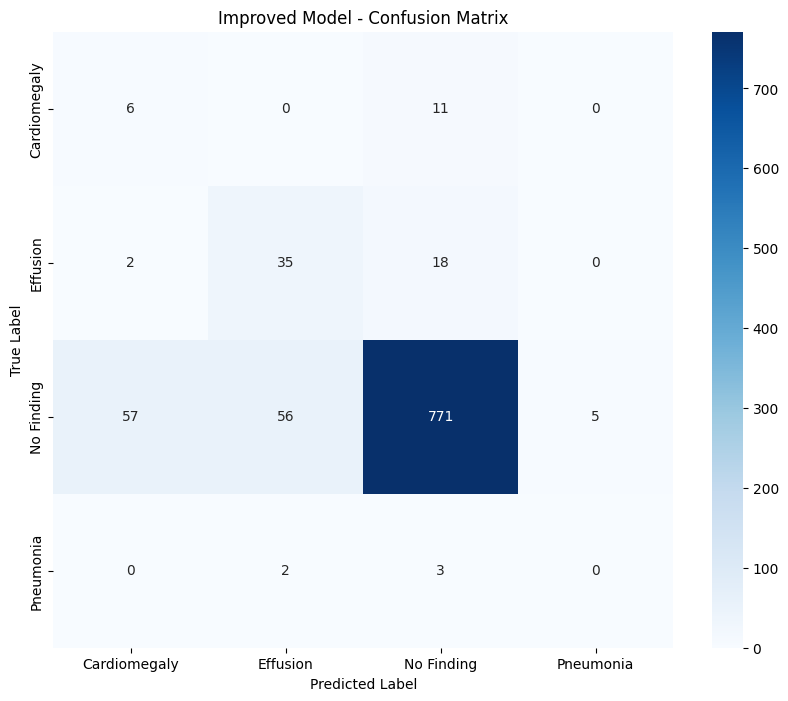

In [15]:
# Evaluate Improved Model with F1-score visualization

# Load best model
model_improved.load_state_dict(torch.load('best_improved_model.pth'))

# Evaluate on test set
test_loss, test_acc, test_preds_improved, test_labels_improved = evaluate_improved(
    model_improved, test_loader_improved, criterion_improved, device, verbose=True
)

print("=" * 60)
print("IMPROVED MODEL RESULTS")
print("=" * 60)
print(f"Final Test: Loss={test_loss:.4f}, Acc={test_acc:.4f}")
print()

# Import necessary libraries for detailed metrics
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

# Detailed classification report
print("Classification Report:")
print(classification_report(test_labels_improved, test_preds_improved, target_names=TARGET_DISEASES))

# Confusion Matrix
cm_improved = confusion_matrix(test_labels_improved, test_preds_improved)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Blues',
            xticklabels=TARGET_DISEASES, yticklabels=TARGET_DISEASES)
plt.title('Improved Model - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
